In [ ]:
!pip install kaggle

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
!kaggle datasets download -d kazanova/sentiment140

Dataset URL: https://www.kaggle.com/datasets/kazanova/sentiment140
License(s): other
 91% 74.0M/80.9M [00:01<00:00, 86.1MB/s]
100% 80.9M/80.9M [00:01<00:00, 76.6MB/s]


In [ ]:
from zipfile import ZipFile
dataset = '/content/sentiment140.zip'

with ZipFile(dataset,'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [ ]:
import numpy as np
import pandas as pd
import re
import nltk
from nltk.stem.porter import PorterStemmer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score ,confusion_matrix,classification_report,precision_score,recall_score,roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import GridSearchCV

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
print(stopwords.words('english'))

['i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', "you're", "you've", "you'll", "you'd", 'your', 'yours', 'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', "she's", 'her', 'hers', 'herself', 'it', "it's", 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves', 'what', 'which', 'who', 'whom', 'this', 'that', "that'll", 'these', 'those', 'am', 'is', 'are', 'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does', 'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until', 'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into', 'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down', 'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here', 'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more', 'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so', 'than', '

In [ ]:
twitter_data = pd.read_csv('/content/training.1600000.processed.noemoticon.csv',encoding='ISO-8859-1')

In [ ]:
twitter_data.shape

(1599999, 6)

In [ ]:
twitter_data.head()

,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [ ]:
colums = ['target','ids','date','flag','user','text']
twitter_data.columns = colums

In [ ]:
twitter_data.head()

,target,ids,date,flag,user,text
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [ ]:
twitter_data.isnull().sum()

,0
target,0
ids,0
date,0
flag,0
user,0
text,0


In [ ]:
twitter_data.shape

(1599999, 6)

In [ ]:
colums = ['target','id','date','flag','user','text']
twitter_data = pd.read_csv('/content/training.1600000.processed.noemoticon.csv',encoding='ISO-8859-1',names=colums)

In [ ]:
twitter_data.shape

(1600000, 6)

In [ ]:
twitter_data.head()

,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [ ]:
twitter_data['target'].value_counts()

,count
target,
0,800000
4,800000


In [ ]:
twitter_data.isnull().sum()

,0
target,0
id,0
date,0
flag,0
user,0
text,0


In [ ]:
twitter_data.replace({'target':{4:1}},inplace=True)

In [ ]:
twitter_data['target'].value_counts()

,count
target,
0,800000
1,800000


In [ ]:
port_stem = PorterStemmer()

In [ ]:
def stemming(content):
  stemmed_content = re.sub('[^a-zA-Z]',' ',content)
  stemmed_content = stemmed_content.lower()
  stemmed_content = stemmed_content.split()
  stemmed_content = [port_stem.stem(word) for word in stemmed_content if not word in stopwords.words('english')]
  stemmed_content = ' '.join(stemmed_content)
  return stemmed_content

In [ ]:
twitter_data['stemmed_content'] = twitter_data['text'].apply(stemming)

KeyboardInterrupt: 

In [ ]:
twitter_data.head()

In [ ]:
print(twitter_data['stemmed_content'])

0          switchfoot http twitpic com zl awww bummer sho...
1          upset updat facebook text might cri result sch...
2          kenichan dive mani time ball manag save rest g...
3                            whole bodi feel itchi like fire
4                              nationwideclass behav mad see
                                 ...                        
1599995                           woke school best feel ever
1599996    thewdb com cool hear old walt interview http b...
1599997                         readi mojo makeov ask detail
1599998    happi th birthday boo alll time tupac amaru sh...
1599999    happi charitytuesday thenspcc sparkschar speak...
Name: stemmed_content, Length: 1600000, dtype: object


In [ ]:
print(twitter_data['target'])

0          0
1          0
2          0
3          0
4          0
          ..
1599995    1
1599996    1
1599997    1
1599998    1
1599999    1
Name: target, Length: 1600000, dtype: int64


In [ ]:
X = twitter_data['stemmed_content'].values
Y = twitter_data['target'].values

In [ ]:
print(X)

['switchfoot http twitpic com zl awww bummer shoulda got david carr third day'
 'upset updat facebook text might cri result school today also blah'
 'kenichan dive mani time ball manag save rest go bound' ...
 'readi mojo makeov ask detail'
 'happi th birthday boo alll time tupac amaru shakur'
 'happi charitytuesday thenspcc sparkschar speakinguph h']


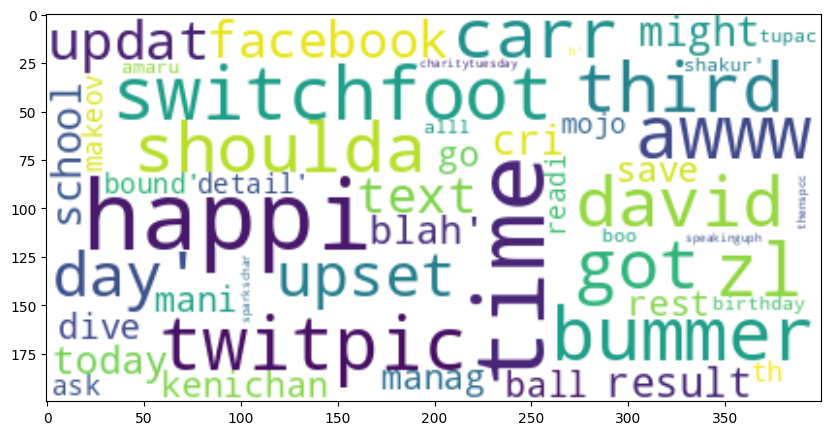

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

plt.rcParams['figure.figsize'] = 10,10
word_cloud = WordCloud(max_font_size=50,max_words=100,background_color='white').generate(str(X))
plt.imshow(word_cloud,interpolation='bilinear')
plt.show()

In [ ]:
print(Y)

[0 0 0 ... 1 1 1]


In [ ]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,stratify=Y,random_state=2)

In [ ]:
print(X.shape,X_train.shape,X_test.shape)

(1600000,) (1280000,) (320000,)


In [ ]:
print(X_train)


['watch saw iv drink lil wine' 'hatermagazin'
 'even though favourit drink think vodka coke wipe mind time think im gonna find new drink'
 ... 'eager monday afternoon'
 'hope everyon mother great day wait hear guy store tomorrow'
 'love wake folger bad voic deeper']


In [ ]:
print(X_test)


['mmangen fine much time chat twitter hubbi back summer amp tend domin free time'
 'ah may show w ruth kim amp geoffrey sanhueza'
 'ishatara mayb bay area thang dammit' ...
 'destini nevertheless hooray member wonder safe trip' 'feel well'
 'supersandro thank']


In [ ]:
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(X_train)
X_test = vectorizer.transform(X_test)

In [ ]:
print(X_train)

  (0, 443066)	0.4484755317023172
  (0, 235045)	0.41996827700291095
  (0, 109306)	0.3753708587402299
  (0, 185193)	0.5277679060576009
  (0, 354543)	0.3588091611460021
  (0, 436713)	0.27259876264838384
  (1, 160636)	1.0
  (2, 288470)	0.16786949597862733
  (2, 132311)	0.2028971570399794
  (2, 150715)	0.18803850583207948
  (2, 178061)	0.1619010109445149
  (2, 409143)	0.15169282335109835
  (2, 266729)	0.24123230668976975
  (2, 443430)	0.3348599670252845
  (2, 77929)	0.31284080750346344
  (2, 433560)	0.3296595898028565
  (2, 406399)	0.32105459490875526
  (2, 129411)	0.29074192727957143
  (2, 407301)	0.18709338684973031
  (2, 124484)	0.1892155960801415
  (2, 109306)	0.4591176413728317
  (3, 172421)	0.37464146922154384
  (3, 411528)	0.27089772444087873
  (3, 388626)	0.3940776331458846
  (3, 56476)	0.5200465453608686
  :	:
  (1279996, 390130)	0.22064742191076112
  (1279996, 434014)	0.2718945052332447
  (1279996, 318303)	0.21254698865277746
  (1279996, 237899)	0.2236567560099234
  (1279996, 2910

In [ ]:
print(X_test)

  (0, 420984)	0.17915624523539803
  (0, 409143)	0.31430470598079707
  (0, 398906)	0.3491043873264267
  (0, 388348)	0.21985076072061738
  (0, 279082)	0.1782518010910344
  (0, 271016)	0.4535662391658828
  (0, 171378)	0.2805816206356073
  (0, 138164)	0.23688292264071403
  (0, 132364)	0.25525488955578596
  (0, 106069)	0.3655545001090455
  (0, 67828)	0.26800375270827315
  (0, 31168)	0.16247724180521766
  (0, 15110)	0.1719352837797837
  (1, 366203)	0.24595562404108307
  (1, 348135)	0.4739279595416274
  (1, 256777)	0.28751585696559306
  (1, 217562)	0.40288153995289894
  (1, 145393)	0.575262969264869
  (1, 15110)	0.211037449588008
  (1, 6463)	0.30733520460524466
  (2, 400621)	0.4317732461913093
  (2, 256834)	0.2564939661498776
  (2, 183312)	0.5892069252021465
  (2, 89448)	0.36340369428387626
  (2, 34401)	0.37916255084357414
  :	:
  (319994, 123278)	0.4530341382559843
  (319995, 444934)	0.3211092817599261
  (319995, 420984)	0.22631428606830145
  (319995, 416257)	0.23816465111736276
  (319995, 3

In [ ]:
logistic_model = LogisticRegression(max_iter=1000)

In [ ]:
logistic_model.fit(X_train,Y_train)

LogisticRegression(max_iter=1000)

In [ ]:
# Make predictions on the train set
X_train_prediction = logistic_model.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction,Y_train)
print('Accuracy score of the training data : ', training_data_accuracy)

Accuracy score of the training data :  0.81018984375


In [ ]:
# Make predictions on the test set
X_test_prediction = logistic_model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction,Y_test)
print('Accuracy score of the test data : ', test_data_accuracy)

Accuracy score of the test data :  0.7780375


Confusion Matrix:
 [[121445  38555]
 [ 32473 127527]]
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.76      0.77    160000
           1       0.77      0.80      0.78    160000

    accuracy                           0.78    320000
   macro avg       0.78      0.78      0.78    320000
weighted avg       0.78      0.78      0.78    320000

Precision: 0.7678556375766188
Recall: 0.79704375


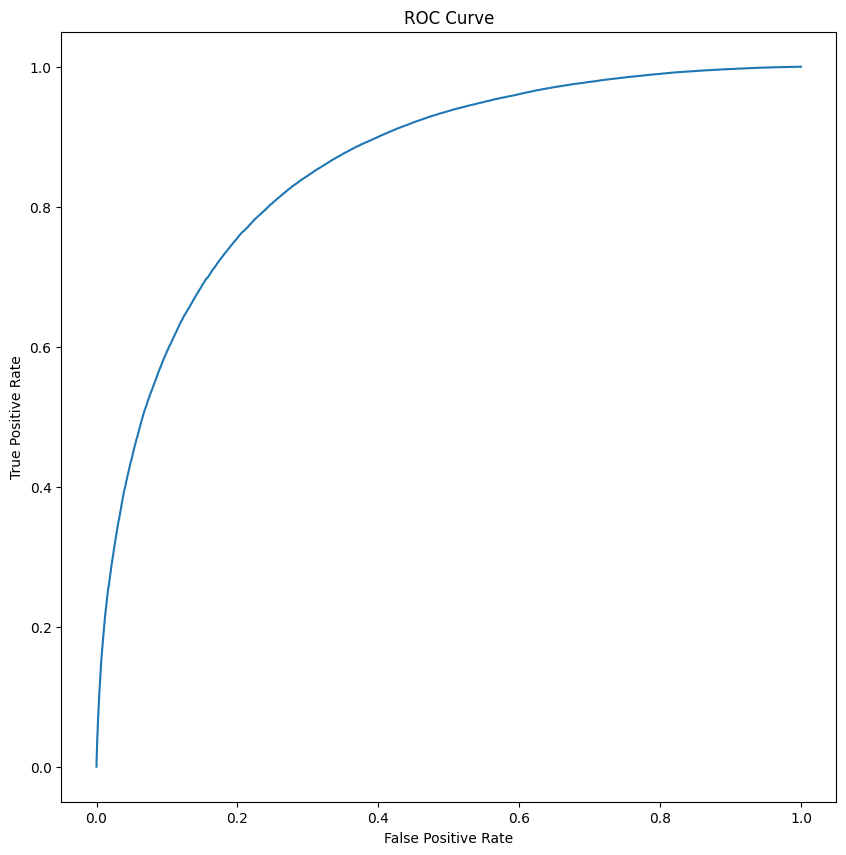

In [ ]:
# Confusion Matrix
confusion_mat = confusion_matrix(Y_test, X_test_prediction)
print("Confusion Matrix:\n", confusion_mat)

# Classification Report
class_report = classification_report(Y_test, X_test_prediction)
print("Classification Report:\n", class_report)

# Precision and Recall
precision = precision_score(Y_test, X_test_prediction)
recall = recall_score(Y_test, X_test_prediction)
print("Precision:", precision)
print("Recall:", recall)

# ROC Curve (if applicable for binary classification)
if len(np.unique(Y_test)) == 2:
  y_pred_proba = logistic_model.predict_proba(X_test)[:, 1]
  fpr, tpr, thresholds = roc_curve(Y_test, y_pred_proba)
  plt.plot(fpr, tpr)
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.title('ROC Curve')
  plt.show()


# SVM model

In [ ]:
from sklearn.svm import SVC

In [ ]:
# Create an SVM model
svm_model = SVC(kernel='linear')

In [ ]:
# Train the model
svm_model.fit(X_train, Y_train)

In [ ]:
# Make predictions on the train set
X_train_prediction = svm_model.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)
print('Accuracy score of the training data : ', training_data_accuracy)

In [ ]:
# Make predictions on the test set
X_test_prediction = svm_model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)
print('Accuracy score of the test data : ', test_data_accuracy)

In [ ]:
# Confusion Matrix
svm_confusion_mat = confusion_matrix(Y_test, X_test_prediction)
print("SVM Confusion Matrix:\n", svm_confusion_mat)

# Classification Report
svm_class_report = classification_report(Y_test, X_test_prediction)
print("SVM Classification Report:\n", svm_class_report)

# Precision and Recall
svm_precision = precision_score(Y_test, X_test_prediction)
svm_recall = recall_score(Y_test, X_test_prediction)
print("SVM Precision:", svm_precision)
print("SVM Recall:", svm_recall)



```
# This is formatted as code
```

# Decision Tree

In [ ]:
import sklearn
from sklearn.tree import DecisionTreeClassifier

In [ ]:
# Create a Decision Tree model
dt_model = DecisionTreeClassifier()

In [ ]:
# Train the model
dt_model.fit(X_train, Y_train)

In [ ]:
# Make predictions on the train set
X_train_prediction = dt_model.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)
print('Accuracy score of the training data : ', training_data_accuracy)

In [ ]:
# Make predictions on the test set
X_test_prediction = dt_model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)
print('Accuracy score of the test data : ', test_data_accuracy)

In [ ]:
# Confusion Matrix
dt_confusion_mat = confusion_matrix(Y_test, X_test_prediction)
print("Decision Tree Confusion Matrix:\n", dt_confusion_mat)

# Classification Report
dt_class_report = classification_report(Y_test, X_test_prediction)
print("Decision Tree Classification Report:\n", dt_class_report)

# Precision and Recall
dt_precision = precision_score(Y_test, X_test_prediction)
dt_recall = recall_score(Y_test, X_test_prediction)
print("Decision Tree Precision:", dt_precision)
print("Decision Tree Recall:", dt_recall)

# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Create a Random Forest model
rf_model = RandomForestClassifier()

In [ ]:
# Train the model
rf_model.fit(X_train, Y_train)

In [ ]:
# Make predictions on the train set
X_train_prediction = rf_model.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)
print('Accuracy score of the training data : ', training_data_accuracy)

In [ ]:
# Make predictions on the test set
X_test_prediction = rf_model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)
print('Accuracy score of the test data : ', test_data_accuracy)

In [ ]:
# Confusion Matrix
rf_confusion_mat = confusion_matrix(Y_test, X_test_prediction)
print("Confusion Matrix:\n", rf_confusion_mat)

# Classification Report
rf_class_report = classification_report(Y_test, X_test_prediction)
print("Classification Report:\n", rf_class_report)

# Precision and Recall
rf_precision = precision_score(Y_test, X_test_prediction)
rf_recall = recall_score(Y_test, X_test_prediction)
print("Precision:", rf_precision)
print("Recall:", rf_recall)

In [ ]:
# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [ ]:
# Create a Random Forest model
rf_model_best = RandomForestClassifier()

In [ ]:
# Create a GridSearchCV object
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid,
                           cv=5, n_jobs=-1, verbose=2)

# Fit the GridSearchCV object to the data
grid_search.fit(X_train, Y_train)

In [ ]:
# Print the best parameters and the best score
print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

In [ ]:
# Train a new model with the best parameters
best_rf_model = RandomForestClassifier(**grid_search.best_params_)
best_rf_model.fit(X_train, Y_train)

In [ ]:
# Make predictions on the train set
X_train_prediction = best_rf_model.predict(X_train)
training_data_accuracy = accuracy_score(X_train_prediction, Y_train)
print('Accuracy score of the training data with best parameters : ', training_data_accuracy)

In [ ]:
# Make predictions on the test set
X_test_prediction = best_rf_model.predict(X_test)
test_data_accuracy = accuracy_score(X_test_prediction, Y_test)
print('Accuracy score of the test data with best parameters : ', test_data_accuracy)

In [ ]:
# Confusion Matrix
confusion_matrix = confusion_matrix(Y_test, X_test_prediction)
print("Confusion Matrix:\n", confusion_matrix)

# Classification Report
class_report = classification_report(Y_test, X_test_prediction)
print("Classification Report:\n", class_report)

# Precision and Recall
precision = precision_score(Y_test, X_test_prediction)
recall = recall_score(Y_test, X_test_prediction)
print("Precision:", precision)
print("Recall:", recall)

In [ ]:
import pickle
filename = 'sentiment_analysis_model.sav'
pickle.dump(logistic_model,open(filename,'wb'))
lodaded_model = pickle.load(open(filename,'rb'))

In [ ]:
X_new = X_test[322]
print(Y_test[322])

Y_pred = lodaded_model.predict(X_new)
print(Y_pred)

if (Y_pred[0]==0):
  print('Negative tweet')
else:
  print('Positive tweet')

In [ ]:
X_new = X_test[32]
print(Y_test[32])

Y_pred = lodaded_model.predict(X_new)
print(Y_pred)

if (Y_pred[0]==0):
  print('Negative tweet')
else:
  print('Positive tweet')

In [ ]:
X_new = X_test[2]
print(Y_test[2])

Y_pred = lodaded_model.predict(X_new)
print(Y_pred)

if (Y_pred[0]==0):
  print('Negative tweet')
else:
  print('Positive tweet')

In [ ]:
X_new = X_test[32200]
print(Y_test[32200])

Y_pred = lodaded_model.predict(X_new)
print(Y_pred)

if (Y_pred[0]==0):
  print('Negative tweet')
else:
  print('Positive tweet')

In [ ]:
X_new = X_test[200000]
print(Y_test[200000])

Y_pred = lodaded_model.predict(X_new)
print(Y_pred)

if (Y_pred[0]==0):
  print('Negative tweet')
else:
  print('Positive tweet')

In [ ]:
X_test.shape

In [ ]:
print(X_test.shape)

In [ ]:
X_new = X_test[10000]
print(Y_test[10000])

Y_pred = lodaded_model.predict(X_new)
print(Y_pred)

if (Y_pred[0]==0):
  print('Negative tweet')
else:
  print('Positive tweet')